In [13]:
import tensorflow as tf


(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

print(len(X_train_mnist))
print(len(X_train_cifar))

X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

X_train_cifar = X_train_cifar / 255.0
X_test_cifar = X_test_cifar / 255.0

X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

print(X_train_mnist.shape)
print(X_test_mnist.shape)

print(X_train_cifar.shape)
print(X_test_cifar.shape)

print(y_train_mnist.shape)
print(y_train_cifar.shape)


60000
50000
(60000, 28, 28, 1)
(10000, 28, 28, 1)
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(60000,)
(50000, 1)


In [14]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU')
)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
from tensorflow.keras import layers, models

In [27]:
import time
from tensorflow.keras.callbacks import ReduceLROnPlateau

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       epochs=20, batch_size=64, val_split=0.1):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
    )

    start = time.time()
    history = model.fit(X_train,
                        y_train, epochs=epochs,
                        batch_size=batch_size,
                        validation_split=val_split,
                        callbacks = [lr_scheduler],
                        verbose=1)
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    model_size = model.count_params()

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Training Time: {train_time:.2f}s")
    print(f"  Model Size:    {model_size:,} parameters")

    return {
        'history': history.history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'train_time': train_time,
        'model_size': model_size,
        'model': model
    }

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_results(result, X_test, y_test):

    h = result['history']
    model = result['model']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h['loss'], label='Train Loss')
    axes[0].plot(h['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(h['accuracy'], label='Train Acc')
    axes[1].plot(h['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'Accuracy: (Test: {result["test_acc"]:.4f})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    y_true = y_test.flatten()

    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [28]:
from tensorflow.keras import layers, models

def original_model_choosing(input_size) :

    original_model = models.Sequential([

        layers.Conv2D(32, kernel_size=(3, 3), input_shape= input_size, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        # layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(256),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')
    ])

    return original_model

In [19]:
def alex_net_choosing(input_size) :
    alex_net_model = models.Sequential([
        layers.Conv2D(96, kernel_size = (3, 3), strides = (1, 1), input_shape = input_size, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Dropout(0.1),


        layers.Conv2D(256, kernel_size = (3, 3), strides = (1, 1), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Dropout(0.1),


        layers.Conv2D(384, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.Dropout(0.1),

        layers.Conv2D(384, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.Dropout(0.1),

        layers.Conv2D(256, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides = (2, 2)),
        layers.Dropout(0.1),

        layers.Flatten(),

        layers.Dense(1024),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(512),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(10),
        layers.Activation('softmax')
    ])

    return alex_net_model


In [34]:
original_model_aug = original_model_choosing((32, 32, 3))
alex_net_model_cifar_aug = alex_net_choosing((32, 32, 3))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def augment_data(X_train, y_train, num_augmented_batches=10):

    datagen = ImageDataGenerator(
        horizontal_flip=True,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1
    )

    augmented_images = []
    augmented_labels = []

    batches = 0
    for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=len(X_train)):
        augmented_images.append(X_batch)
        augmented_labels.append(y_batch)
        batches += 1
        if batches >= num_augmented_batches:
            break

    X_aug = np.concatenate([X_train] + augmented_images)
    y_aug = np.concatenate([y_train] + augmented_labels)

    shuffle_idx = np.random.permutation(len(X_aug))
    X_aug = X_aug[shuffle_idx]
    y_aug = y_aug[shuffle_idx]

    print(f"Original: {len(X_train)}, Augmented: {len(X_aug)}")
    return X_aug, y_aug

In [29]:
X_aug_train_cifar, y_aug_train_cifar = augment_data(X_train_cifar, y_train_cifar, num_augmented_batches=1)

Original: 50000, Augmented: 100000


In [32]:
original_model_aug = original_model_choosing((32, 32, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4307 - loss: 1.5673 - val_accuracy: 0.5605 - val_loss: 1.2436 - learning_rate: 5.0000e-04
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5536 - loss: 1.2323 - val_accuracy: 0.5572 - val_loss: 1.2230 - learning_rate: 5.0000e-04
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6072 - loss: 1.0982 - val_accuracy: 0.6254 - val_loss: 1.0549 - learning_rate: 5.0000e-04
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6375 - loss: 1.0099 - val_accuracy: 0.6684 - val_loss: 0.9410 - learning_rate: 5.0000e-04
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6645 - loss: 0.9417 - val_accuracy: 0.6993 - val_loss: 0.8671 - learning_rate: 5.0000e-04
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6833 - loss: 0.8871 - val_accuracy: 0.7181 - val_loss: 0.8138 - learning_rate: 5.0000e-04
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/st

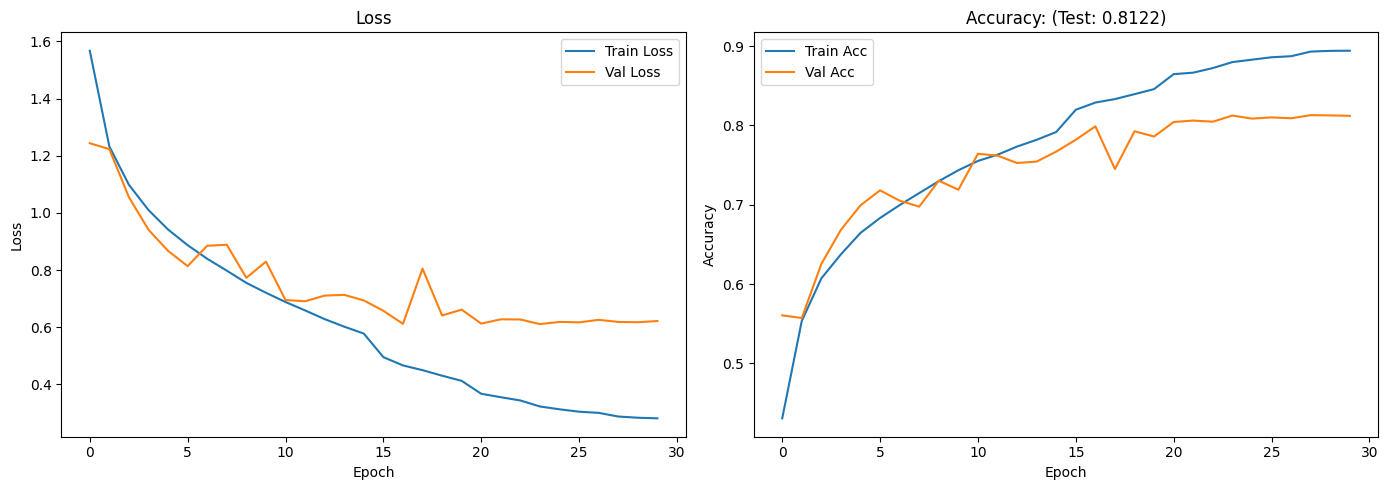

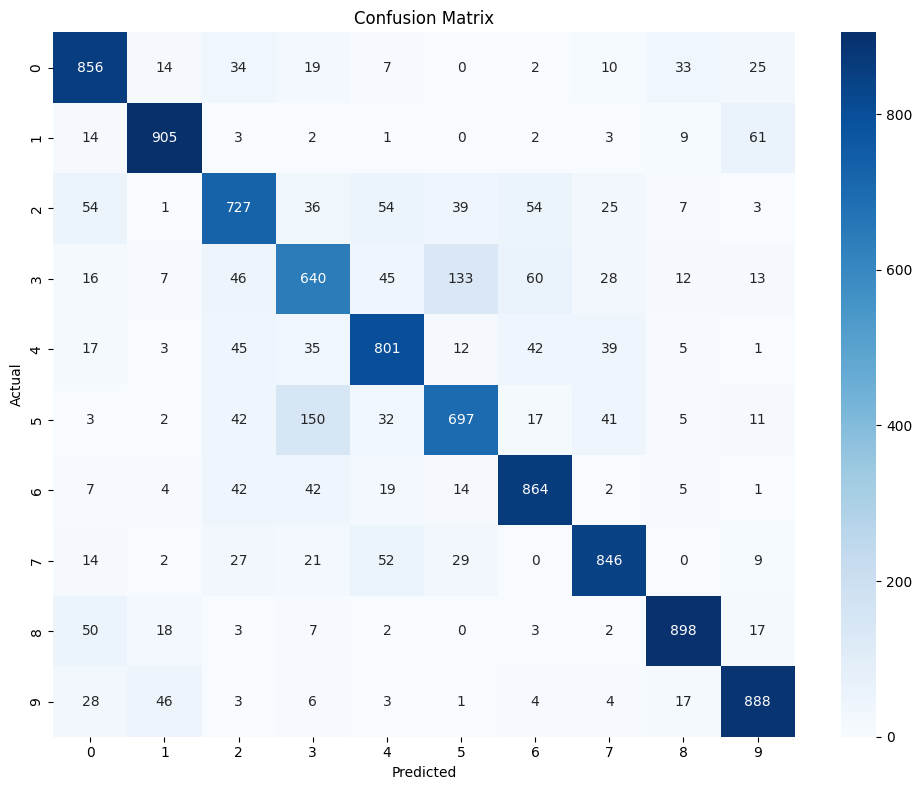

In [33]:
analytics_original = train_and_evaluate(original_model_aug, X_aug_train_cifar, y_aug_train_cifar, X_test_cifar, y_test_cifar, epochs=30)
plot_results(analytics_original, X_test_cifar, y_test_cifar)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.4667 - loss: 1.4672 - val_accuracy: 0.6180 - val_loss: 1.0973 - learning_rate: 5.0000e-04
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6406 - loss: 1.0326 - val_accuracy: 0.6639 - val_loss: 0.9652 - learning_rate: 5.0000e-04
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7026 - loss: 0.8609 - val_accuracy: 0.5680 - val_loss: 1.2988 - learning_rate: 5.0000e-04
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7369 - loss: 0.7642 - val_accuracy: 0.7173 - val_loss: 0.8454 - learning_rate: 5.0000e-04
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7643 - loss: 0.6895 - val_accuracy: 0.7796 - val_loss: 0.6533 - learning_rate: 5.0000e-04
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7830 - loss: 0.6349 - val_accuracy: 0.7307 - val_loss: 0.7784 - learning_rate: 5.0000e-04
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━

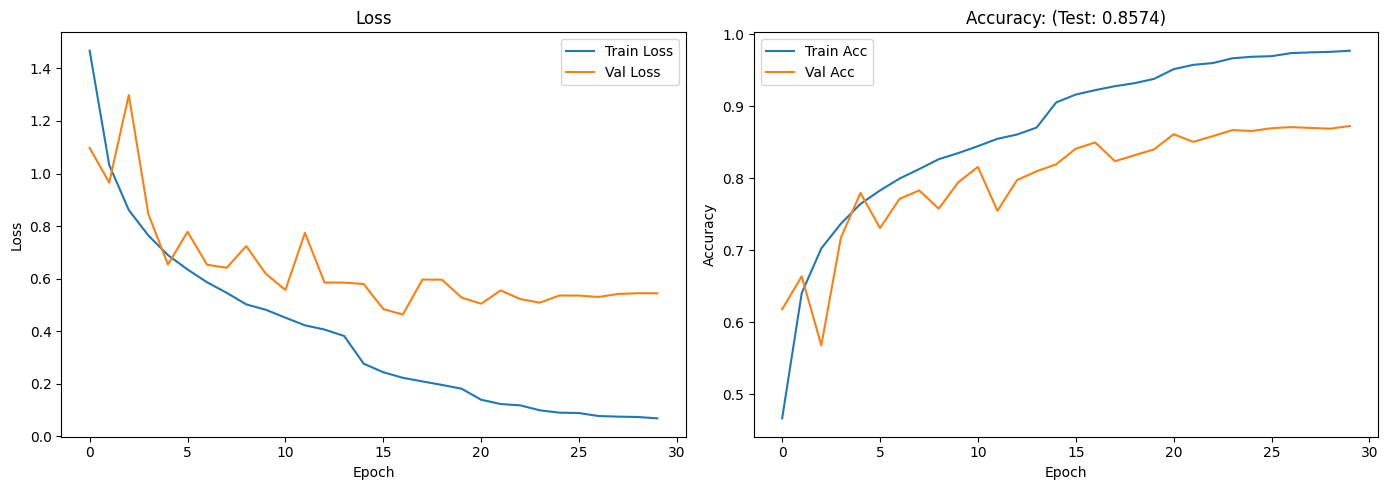

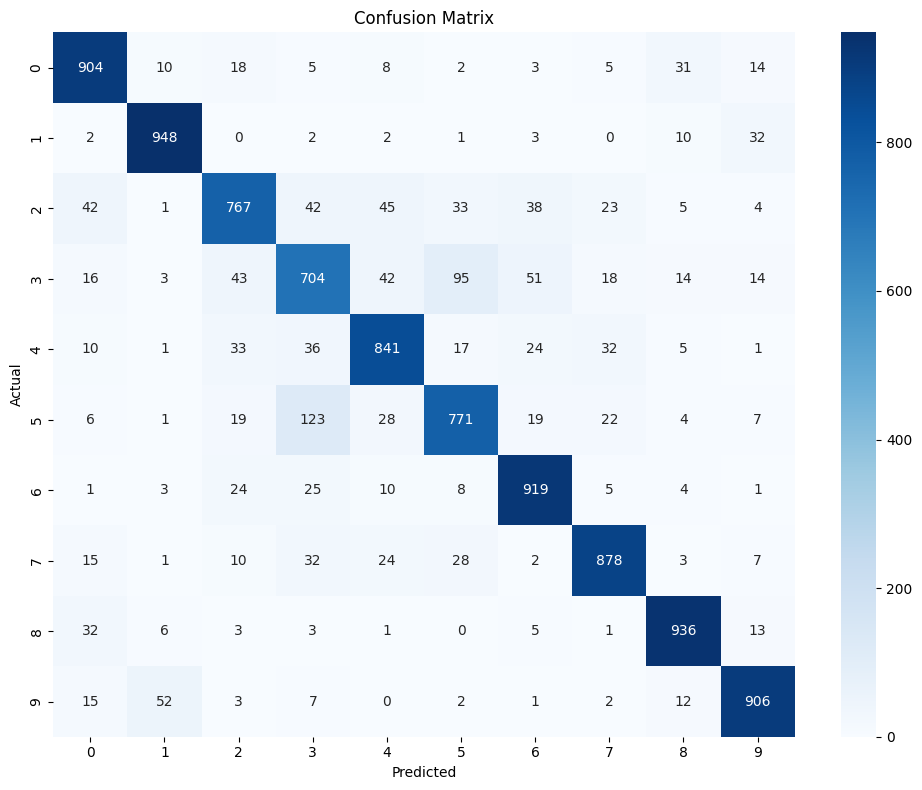

In [35]:
analytics_alex_net = train_and_evaluate(alex_net_model_cifar_aug, X_aug_train_cifar, y_aug_train_cifar, X_test_cifar, y_test_cifar, epochs=30)
plot_results(analytics_alex_net, X_test_cifar, y_test_cifar)